###  Imports

In [1]:
import os
import pandas as pd
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt
#import matplotlib.image as mpimg
#from PIL import Image
from skimage import transform, io
from sklearn.model_selection import train_test_split

#For duplicates
import hashlib

#from scipy.misc import imread, imresize, imshow
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
%matplotlib inline
import warnings
warnings.filterwarnings("ignore")

In [2]:
import tensorflow as tf
# Ensure TensorFlow version 2.x
print("version =",tf.__version__) 

version = 2.2.0


### Preliminary data Preparation and Analysis 

In [3]:
#Unique labels for Images
LABELS = ['Black-grass', 'Charlock', 'Cleavers', 'Common Chickweed', 'Common wheat', 'Fat Hen', 'Loose Silky-bent',
              'Maize', 'Scentless Mayweed', 'Shepherds Purse', 'Small-flowered Cranesbill', 'Sugar beet']

In [4]:
data_dir = '.' #/content/drive/My Drive/GreatLakes/CNN'
train_dir = os.path.join(data_dir, 'train_bk')
test_dir = os.path.join(data_dir, 'test_bk')

### Analyze the Data - Train
Populate all images of each category folder in a train dataframe and analyze train dataset. keras image_dataset_from_directory can also be used but doing it manually here


In [5]:
category_dir =[]
for category in LABELS:
    currentcategory_dir = os.path.join(train_dir, category)
    category_dir.append(currentcategory_dir)
    print(currentcategory_dir)
    print("{}  {} images ".format(category, len(os.listdir(currentcategory_dir))))

.\train_bk\Black-grass
Black-grass  789 images 
.\train_bk\Charlock
Charlock  1170 images 
.\train_bk\Cleavers
Cleavers  861 images 
.\train_bk\Common Chickweed
Common Chickweed  611 images 
.\train_bk\Common wheat
Common wheat  657 images 
.\train_bk\Fat Hen
Fat Hen  475 images 
.\train_bk\Loose Silky-bent
Loose Silky-bent  654 images 
.\train_bk\Maize
Maize  663 images 
.\train_bk\Scentless Mayweed
Scentless Mayweed  516 images 
.\train_bk\Shepherds Purse
Shepherds Purse  693 images 
.\train_bk\Small-flowered Cranesbill
Small-flowered Cranesbill  496 images 
.\train_bk\Sugar beet
Sugar beet  1152 images 


In [6]:
# Minimum number of images in any category is 221 and maximum is 654. IN the folder with maximum number of images,
#many images seem redundant or meaningless because of size and clarity. so we can do some sampling further down
IMAGE_PER_CATEGORY = 220

In [7]:
trainList=[]
trainImages = []

for i, dir in enumerate(category_dir):
    for file in os.listdir(dir):
        
        img = io.imread(train_dir +'//'+ LABELS[i] + '//' + file)
        trainImages.append(img)
        shape = img.shape
        trainList.append([file,LABELS[i], i, shape])
        


In [8]:
train_df = pd.DataFrame(data=trainList, columns=['file','species', 'id', 'shape']) 

train_df.head(100)

,file,species,id,shape
0,0050f38b3.png,Black-grass,0,"(196, 196, 3)"
1,0183fdf68.png,Black-grass,0,"(388, 388, 3)"
2,0260cffa8.png,Black-grass,0,"(886, 886, 3)"
3,05eedce4d.png,Black-grass,0,"(117, 117, 3)"
4,075d004bc.png,Black-grass,0,"(471, 471, 3)"
...,...,...,...,...
95,0bl_4f48eb987.png,Black-grass,0,"(906, 906, 3)"
96,0bl_5212d8564.png,Black-grass,0,"(1435, 1435, 3)"
97,0bl_5296a06e6.png,Black-grass,0,"(1030, 1030, 3)"
98,0bl_53ab7a3da.png,Black-grass,0,"(351, 351, 3)"


In [9]:
train_df.describe()

,id
count,8737.000000
mean,5.298157
std,3.728238
min,0.000000
25%,2.000000
50%,5.000000
75%,9.000000
max,11.000000


In [10]:
train_df.describe(include='object')

,file,species,shape
count,8737,8737,8737
unique,8737,12,1009
top,0un_f135a739f.png,Charlock,"(115, 115, 3)"
freq,1,1170,58


In [11]:
train_df.shape

(8737, 4)

In [12]:
train_df.head()

,file,species,id,shape
0,0050f38b3.png,Black-grass,0,"(196, 196, 3)"
1,0183fdf68.png,Black-grass,0,"(388, 388, 3)"
2,0260cffa8.png,Black-grass,0,"(886, 886, 3)"
3,05eedce4d.png,Black-grass,0,"(117, 117, 3)"
4,075d004bc.png,Black-grass,0,"(471, 471, 3)"


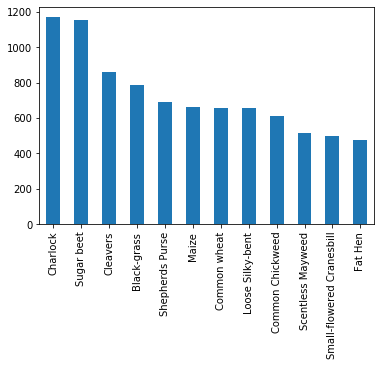

In [13]:
# Plot of label types numbers
speciesCounts = train_df['species'].value_counts()
speciesCounts.plot(kind='bar')

#imbalanced data , few categories have almost the three times the images' count than ones with minimum image count 

In [14]:
# Plot of label types numbers
train_df['shape'].value_counts()


(115, 115, 3)      58
(163, 163, 3)      47
(155, 155, 3)      47
(150, 150, 3)      46
(154, 154, 3)      45
                   ..
(760, 760, 3)       1
(3457, 3991, 3)     1
(1234, 1234, 3)     1
(748, 748, 3)       1
(442, 442, 3)       1
Name: shape, Length: 1009, dtype: int64

In [15]:
minimum_size_img = min(train_df['shape'])
print(minimum_size_img)

(49, 49, 3)


In [16]:
maximum_size_img = max(train_df['shape'])
print(maximum_size_img)

(3457, 3991, 3)


In [17]:


test = []
for file in os.listdir(test_dir):
    test.append([file])
test_df = pd.DataFrame(test, columns=['file'])
test_df.shape

(794, 1)

In [18]:
test_df.head()

,file
0,0021e90e4.png
1,003d61042.png
2,007b3da8b.png
3,0086a6340.png
4,00c47e980.png


### Take a Look at Images - Try Different

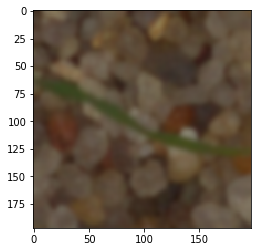

In [19]:
img = io.imread(train_dir +'//'+ train_df.loc[200, 'species'] + '//' + train_df.loc[200,'file'])
plt.imshow(img)
#Object of interest seems very blurred here

Randomly checked many training images and many images have blurring
1. Loose silky belt has maximum images of various sizes

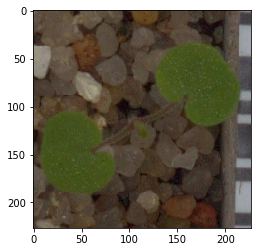

In [20]:
img = io.imread(test_dir +'//'+  test_df.loc[70,'file'])
plt.imshow(img)

Checked randomly almost all Test images at disk. Most of the images are clear and few images seem to be cropped or lying towards the edge  

In [21]:
### Function for plotting first few images of dataset

In [22]:
import random

def plotImages(data):
    # plot random images
    randomList = []

    # Set a length of the list to 10
    for i in range(0, 10):
        # any random numbers from 0 to length of data array
        randomList.append(random.randint(0, len(data)-1))
    j=0
    for i in randomList:
        # define subplot pos is a three digit integer, where the first digit is the number of rows, 
        #the second the number of columns, and the third is the index of the subplot. We are updating
        # index of subplot by adding 1+i as index starts from 1 from left hand corner.
        plt.subplot(330 + 1 + j)
        plt.imshow(data[i])
        j = j+1
        if (j==9):
            break
    # show the figure
    plt.show()


### Data PreProcessing - Imblance removal


1. Dataset is imbalanced so we can try downsampling categories which have more images

In [23]:
def downSampleData():
    sampled_df = pd.DataFrame(columns=train_df.columns)
    
    for l in LABELS:
        subset_df = train_df[train_df['species'] == l]
        subset_df = subset_df.sample(IMAGE_PER_CATEGORY)
        sampled_df = pd.concat[sampled_df, subset_df]
        
    train_df = sampled_df
    train_df.index = np.arange(len(train_df))
    train_df.head(2)
    train_df.shape

In [24]:
def upSampleData():
    import os
    from PIL import Image
    from PIL import ImageFilter
    
    os.chdir(data_dir)
    current = os.getcwd()
    #current = os.chdir(train_dir) 
    print(current)
    #filelist = train['Image'].loc[(train['cnt_freq']<10)].tolist()
    normalizedCount = train_df['species'].value_counts(normalize=True)
    # Get the species whose count is very low
    lowDataSpecies = normalizedCount[normalizedCount.values<0.1].index
    
    #print(speciesCount)
    
    #for count in range(0,1):
        #for index, dir in  enumerate(category_dir):
    count =0
    for species in lowDataSpecies:
        #print(dir)
        directory = (train_dir+"\\"+species) 
        print(directory)
        #os.chdir(train_dir +'//')
        file_list = os.listdir(directory)

        for file in file_list:
            filename = directory+"\\"+file
            if  (os.path.isfile(filename)):
                print("sampling of ",filename)
                im=Image.open(filename)
                im=im.convert("RGB")
                #r,g,b=im.split()
                #r=r.convert("RGB")
                #g=g.convert("RGB")
                #b=b.convert("RGB")
                im_blur=im.filter(ImageFilter.GaussianBlur)
                im_unsharp=im.filter(ImageFilter.UnsharpMask)

                copypath = directory+"\\" +"copy"
                print("copy to",copypath)

                print(copypath+"\\"+str(count)+'bl_'+file)
                #r.save(copypath+"\\"+str(count)+'r_'+file,'PNG')
                #g.save(copypath+"\\"+str(count)+'g_'+file,'PNG')
                #b.save(copypath+"\\"+str(count)+'b_'+file, 'PNG')
                im_blur.save(copypath+"\\"+str(count)+'bl_'+file,'PNG')
                im_unsharp.save(copypath+"\\"+str(count)+'un_'+file,'PNG')


In [25]:
#upSampleData()

#Upsampling of Image data set has been done and stored at disk. To save time for subsequent execution, the upsmpling wont be repeated

### Digital Image Pre Processing - Resizing and Normalization
The aim of digital image processing is to improve the image data (features) by suppressing unwanted distortions 
and/or enhancement of some important image features so that our AI-Computer Vision models can benefit from 
this improved data to work on.

In [26]:
def resize_img_bk(new_shape):
    listResized = []

    for i in (train_dir +'//'+ train_df['species'] + '//' + train_df['file']):
        #if  (isfile(filename)):
        img = io.imread(i)
        img = np.asarray(img, dtype='float32')
        img = img/255

        data = transform.resize(image=img, output_shape=new_shape)
        listResized.append(data)

    return listResized;

In [27]:
def resize_img(new_shape):
    listResized = []
    for species in LABELS:
        directory = (train_dir+"\\"+species) 
        print(directory)
        #os.chdir(train_dir +'//')
        file_list = os.listdir(directory)

        for file in file_list:
            filename = directory+"\\"+file

    #for i in (train_dir +'//'+ train_df['species'] + '//' + train_df['file']):
        #if  (isfile(filename)):
            img = io.imread(filename)
            img = np.asarray(img, dtype='float32')
            img = img/255

            data = transform.resize(image=img, output_shape=new_shape)
            listResized.append(data)

    return listResized

In [28]:
X = resize_img(minimum_size_img)

.\train_bk\Black-grass
.\train_bk\Charlock
.\train_bk\Cleavers
.\train_bk\Common Chickweed
.\train_bk\Common wheat
.\train_bk\Fat Hen
.\train_bk\Loose Silky-bent
.\train_bk\Maize
.\train_bk\Scentless Mayweed
.\train_bk\Shepherds Purse
.\train_bk\Small-flowered Cranesbill
.\train_bk\Sugar beet


### X and y split

In [29]:
X = (np.array(X))
print(X.shape)
y= np.asarray(train_df['id'])

(8737, 49, 49, 3)


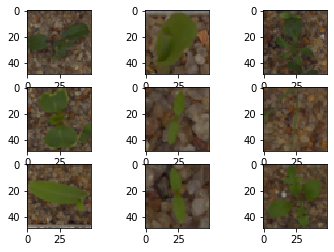

In [30]:
plotImages(X)

### Train And Validation Split

In [31]:
X_train, X_validate, y_train, y_validate = train_test_split(X, y, test_size=0.2, random_state=42)
X_train.shape,y_train.shape

((6989, 49, 49, 3), (6989,))

In [32]:
X_validate.shape,y_validate.shape

((1748, 49, 49, 3), (1748,))

### SMOTE - Data Preprocessing for imbalanced dataset
<=2 expected but 4 dimenion 

### One Hot Encoding of Y 

In [33]:
# Change the labels from categorical to one-hot encoding
train_Y_one_hot = tf.keras.utils.to_categorical(y_train)
validate_Y_one_hot = tf.keras.utils.to_categorical(y_validate)

### Digital Image Pre Processing - Augment Data

In [34]:
def augmentData():
    # This will do preprocessing and realtime data augmentation:
    datagen =  tf.keras.preprocessing.image.ImageDataGenerator(
        rotation_range=90,
        width_shift_range=0.2,
        height_shift_range=0.2,
        horizontal_flip=True,
        vertical_flip=True,
        fill_mode='nearest',
        zoom_range= 0.2
    )

    # Prepare the generator
    datagen.fit(X_train)

    for x_batch, y_batch in datagen.flow(X_train, y_train, batch_size=9):
        # Show the first 9 images
        for i in range(0, 9):
            plt.subplot(330 + 1 + i)
            plt.imshow(x_batch[i].reshape(minimum_size_img[0], minimum_size_img[1], minimum_size_img[2]))
        # show the plot
        plt.show()
        break
    return datagen

### Basic Model Creation

In [35]:
def BuildCNNRelu(shapeIn):
    numclasses = len(LABELS)
    print(numclasses)
    
    cnn_basic = tf.keras.Sequential()
    cnn_basic.add(tf.keras.layers.Conv2D(32, kernel_size=(3,3), activation='linear', input_shape=shapeIn, padding='same'))
    cnn_basic.add(tf.keras.layers.ReLU(alpha=0.1))
    cnn_basic.add(tf.keras.layers.MaxPooling2D((2,2), padding='same'))

    cnn_basic.add(tf.keras.layers.Conv2D(64, kernel_size=(3,3), activation='linear', padding='same'))
    cnn_basic.add(tf.keras.layers.ReLU(alpha=0.1))
    cnn_basic.add(tf.keras.layers.MaxPooling2D((2,2), padding='same'))

    cnn_basic.add(tf.keras.layers.Conv2D(128, kernel_size=(3,3), activation='linear', padding='same'))
    cnn_basic.add(tf.keras.layers.ReLU(alpha=0.1))
    cnn_basic.add(tf.keras.layers.MaxPooling2D((2,2), padding='same'))

    cnn_basic.add(tf.keras.layers.Flatten())
    cnn_basic.add(tf.keras.layers.Dense(50, activation='relu'))
    cnn_basic.add(tf.keras.layers.Dense(numclasses, activation='softmax'))
    

    cnn_basic.compile(loss='sparse_categorical_crossentropy', optimizer=tf.keras.optimizers.Adam(lr=0.001), metrics=['accuracy'])
    return cnn_basic

In [36]:
def BuildCNNBasic(shapeIn):
    numclasses = len(LABELS)
    print(numclasses)
    
    cnn_basic = tf.keras.Sequential()
    cnn_basic.add(tf.keras.layers.Conv2D(32, kernel_size=(3,3), activation='linear', input_shape=shapeIn, padding='same'))
    cnn_basic.add(tf.keras.layers.LeakyReLU(alpha=0.1))
    cnn_basic.add(tf.keras.layers.MaxPooling2D((2,2), padding='same'))

    cnn_basic.add(tf.keras.layers.Conv2D(64, kernel_size=(3,3), activation='linear', padding='same'))
    cnn_basic.add(tf.keras.layers.LeakyReLU(alpha=0.1))
    cnn_basic.add(tf.keras.layers.MaxPooling2D((2,2), padding='same'))

    cnn_basic.add(tf.keras.layers.Conv2D(128, kernel_size=(3,3), activation='linear', padding='same'))
    cnn_basic.add(tf.keras.layers.LeakyReLU(alpha=0.1))
    cnn_basic.add(tf.keras.layers.MaxPooling2D((2,2), padding='same'))

    cnn_basic.add(tf.keras.layers.Flatten())
    cnn_basic.add(tf.keras.layers.Dense(50, activation='relu'))
    cnn_basic.add(tf.keras.layers.Dense(numclasses, activation='softmax'))
    

    cnn_basic.compile(loss='sparse_categorical_crossentropy', optimizer=tf.keras.optimizers.Adam(lr=0.001), metrics=['accuracy'])
    return cnn_basic


### Model with Drop Out - Regularazation of Base Model

In [37]:
def BuildCNNWithDropOut(shapeIn):
    numclasses = len(LABELS)
    print(numclasses)
    
    cnn_dropoutModel = tf.keras.Sequential()
    cnn_dropoutModel.add(tf.keras.layers.Conv2D(32, kernel_size=(3,3), activation='linear', input_shape=shapeIn, padding='same'))
    cnn_dropoutModel.add(tf.keras.layers.LeakyReLU(alpha=0.1))
    cnn_dropoutModel.add(tf.keras.layers.MaxPooling2D((2,2), padding='same'))
    #cnn_dropoutModel.add(tf.keras.layers.Dropout(0.2))

    cnn_dropoutModel.add(tf.keras.layers.Conv2D(64, kernel_size=(3,3), activation='linear', padding='same'))
    cnn_dropoutModel.add(tf.keras.layers.LeakyReLU(alpha=0.1))
    cnn_dropoutModel.add(tf.keras.layers.MaxPooling2D((2,2), padding='same'))
    #cnn_dropoutModel.add(tf.keras.layers.Dropout(0.2))

    cnn_dropoutModel.add(tf.keras.layers.Conv2D(128, kernel_size=(3,3), activation='linear', padding='same'))
    cnn_dropoutModel.add(tf.keras.layers.LeakyReLU(alpha=0.1))
    cnn_dropoutModel.add(tf.keras.layers.MaxPooling2D((2,2), padding='same'))
   # cnn_dropoutModel.add(tf.keras.layers.Dropout(0.1))

    cnn_dropoutModel.add(tf.keras.layers.Flatten())
    cnn_dropoutModel.add(tf.keras.layers.Dense(50, activation='relu'))
    cnn_dropoutModel.add(tf.keras.layers.Dropout(0.25))

    cnn_dropoutModel.add(tf.keras.layers.Dense(numclasses, activation='softmax'))
    
    cnn_dropoutModel.compile(loss='sparse_categorical_crossentropy', optimizer=tf.keras.optimizers.Adam(lr=0.001), metrics=['accuracy'])
    return cnn_dropoutModel

### Model with BatchNormalization - Regularazation of Base Model

In [38]:
def BuildCNNWithBatchNormalization(shapeIn):
    numclasses = len(LABELS)
    print(numclasses)
    
    cnn_dropoutModel = tf.keras.Sequential()
    cnn_dropoutModel.add(tf.keras.layers.BatchNormalization())
    cnn_dropoutModel.add(tf.keras.layers.Conv2D(32, kernel_size=(3,3), activation='linear', input_shape=shapeIn, padding='same'))
    cnn_dropoutModel.add(tf.keras.layers.LeakyReLU(alpha=0.1))
    cnn_dropoutModel.add(tf.keras.layers.MaxPooling2D((2,2), padding='same'))
    cnn_dropoutModel.add(tf.keras.layers.Dropout(0.3))

    cnn_dropoutModel.add(tf.keras.layers.Conv2D(64, kernel_size=(3,3), activation='linear', padding='same'))
    cnn_dropoutModel.add(tf.keras.layers.BatchNormalization())
    cnn_dropoutModel.add(tf.keras.layers.LeakyReLU(alpha=0.1))
    cnn_dropoutModel.add(tf.keras.layers.MaxPooling2D((2,2), padding='same'))
    cnn_dropoutModel.add(tf.keras.layers.Dropout(0.3))

    cnn_dropoutModel.add(tf.keras.layers.Conv2D(128, kernel_size=(3,3), activation='linear', padding='same'))
    cnn_dropoutModel.add(tf.keras.layers.BatchNormalization())
    cnn_dropoutModel.add(tf.keras.layers.LeakyReLU(alpha=0.1))
    cnn_dropoutModel.add(tf.keras.layers.MaxPooling2D((2,2), padding='same'))
    cnn_dropoutModel.add(tf.keras.layers.Dropout(0.2))

    cnn_dropoutModel.add(tf.keras.layers.Flatten())
    cnn_dropoutModel.add(tf.keras.layers.Dense(50, activation='relu'))
    cnn_dropoutModel.add(tf.keras.layers.Dropout(0.2))

    cnn_dropoutModel.add(tf.keras.layers.Dense(numclasses, activation='softmax'))
    
    cnn_dropoutModel.compile(loss='sparse_categorical_crossentropy', optimizer=tf.keras.optimizers.Adam(lr=0.001), metrics=['accuracy'])
    return cnn_dropoutModel

In [39]:
def plot(history): # plot history
    plt.plot(history.history['accuracy'], label='train')
    plt.plot(history.history['val_accuracy'], label='validation')
    plt.legend()
    plt.show()

In [40]:
def predict_classes(test_X):
    predicted_classes = model.predict(test_X)
    predicted_classes = np.argmax(np.round(predicted_classes),axis=1)
    return predicted_classes

In [41]:
def plot_accuracy_error(history):
    accuracy = history.history['accuracy']
    val_accuracy = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs = range(len(accuracy))
    plt.plot(epochs, accuracy, 'bo', label='Training accuracy')
    plt.plot(epochs, val_accuracy, 'b', label='Validation accuracy')
    plt.title('Training and validation accuracy')
    plt.legend()
    plt.figure()
    plt.plot(epochs, loss, 'bo', label='Training loss')
    plt.plot(epochs, val_loss, 'b', label='Validation loss')
    plt.title('Training and validation loss')
    plt.legend()
    plt.show()

In [42]:
def model_accuracy(model, Xtrain, ytrain, Xvalid, yvalid):
    from  sklearn.metrics import accuracy_score, confusion_matrix, classification_report

    print("EVALUATION OF TRAIN :\n")
    loss_and_metrics1 = model.evaluate(Xtrain, ytrain)
    print(loss_and_metrics1)

    print("\nEVALUATION OF VALIDATE :\n")
    loss_and_metrics = model.evaluate(Xvalid, yvalid)
    print(loss_and_metrics)


    #model.predict_proba(X_test)[:, 1]
    y_preds = model.predict_classes(Xvalid)

    #Print the Accuracy score and confusion matrix
    #print("\nACCURACY SCORE IS :\n",accuracy_score(ytest, y_pred))

    print("\nCONFUSION MATRIX FOR ACTUAL vs PREDICTED IS :\n",confusion_matrix(yvalid, y_preds))

    #Print complete classification report
    print("\nCLASSIFICATION REPORT IS :\n")
    print(classification_report(yvalid, y_preds))

### Model Building Of Various Types - Only model giving best result is uncommented which is basic CNN model with no dropouts and batch normalization


In [43]:
BATCH_SIZE = 32
model = BuildCNNBasic(minimum_size_img)#value is (49,49,3)
#,odel = BuildCNNRelu(minimum_size_img)
#model = BuildCNNBasic((128, 128, 3))
#model = BuildCNNBasic((256, 256, 3))
#model = BuildCNNWithDropOut(minimum_size_img)
#model = BuildCNNWithBatchNormalization(minimum_size_img)

12


### Summarize The Model

In [44]:
model.summary()

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv2d (Conv2D)              (None, 49, 49, 32)        896       
_________________________________________________________________
leaky_re_lu (LeakyReLU)      (None, 49, 49, 32)        0         
_________________________________________________________________
max_pooling2d (MaxPooling2D) (None, 25, 25, 32)        0         
_________________________________________________________________
conv2d_1 (Conv2D)            (None, 25, 25, 64)        18496     
_________________________________________________________________
leaky_re_lu_1 (LeakyReLU)    (None, 25, 25, 64)        0         
_________________________________________________________________
max_pooling2d_1 (MaxPooling2 (None, 13, 13, 64)        0         
_________________________________________________________________
conv2d_2 (Conv2D)            (None, 13, 13, 128)       7

### Model fit without augmentation

In [45]:
history = model.fit(X_train, y_train, batch_size=BATCH_SIZE,
                        steps_per_epoch=X_train.shape[0] / BATCH_SIZE,
                        epochs=25,
                        validation_data=(X_validate, y_validate))

Epoch 1/25
219/218 [==============================] - 41s 187ms/step - loss: 1.9565 - accuracy: 0.2983 - val_loss: 1.4529 - val_accuracy: 0.4559
Epoch 2/25
219/218 [==============================] - 38s 174ms/step - loss: 1.1627 - accuracy: 0.5863 - val_loss: 0.9464 - val_accuracy: 0.6716
Epoch 3/25
219/218 [==============================] - 35s 160ms/step - loss: 0.8013 - accuracy: 0.7170 - val_loss: 0.8598 - val_accuracy: 0.6836
Epoch 4/25
219/218 [==============================] - 38s 172ms/step - loss: 0.6581 - accuracy: 0.7686 - val_loss: 0.6885 - val_accuracy: 0.7523
Epoch 5/25
219/218 [==============================] - 38s 173ms/step - loss: 0.4977 - accuracy: 0.8287 - val_loss: 0.5319 - val_accuracy: 0.8198
Epoch 6/25
219/218 [==============================] - 35s 160ms/step - loss: 0.4049 - accuracy: 0.8546 - val_loss: 0.4174 - val_accuracy: 0.8604
Epoch 7/25
219/218 [==============================] - 35s 160ms/step - loss: 0.3054 - accuracy: 0.8958 - val_loss: 0.4525 - val_ac

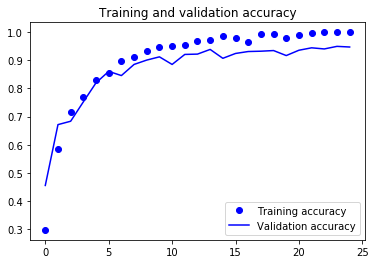

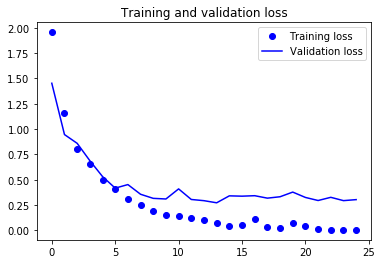

In [46]:
plot_accuracy_error(history)

### Model fit with augmentation
Generalization using data augmentation

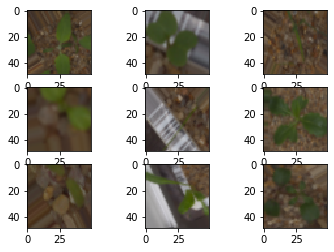

Epoch 1/25
219/218 [==============================] - 40s 183ms/step - loss: 1.3500 - accuracy: 0.5554 - val_loss: 0.6608 - val_accuracy: 0.7878
Epoch 2/25
219/218 [==============================] - 40s 184ms/step - loss: 0.9314 - accuracy: 0.6670 - val_loss: 0.5267 - val_accuracy: 0.8312
Epoch 3/25
219/218 [==============================] - 38s 175ms/step - loss: 0.8145 - accuracy: 0.7133 - val_loss: 0.4501 - val_accuracy: 0.8495
Epoch 4/25
219/218 [==============================] - 38s 173ms/step - loss: 0.7484 - accuracy: 0.7369 - val_loss: 0.4114 - val_accuracy: 0.8518
Epoch 5/25
219/218 [==============================] - 38s 174ms/step - loss: 0.7097 - accuracy: 0.7469 - val_loss: 0.4270 - val_accuracy: 0.8358
Epoch 6/25
219/218 [==============================] - 38s 175ms/step - loss: 0.6492 - accuracy: 0.7715 - val_loss: 0.4027 - val_accuracy: 0.8678
Epoch 7/25
219/218 [==============================] - 41s 186ms/step - loss: 0.6171 - accuracy: 0.7855 - val_loss: 0.3886 - val_ac

In [47]:
datagen = augmentData()
history = model.fit(datagen.flow(X_train, y_train, batch_size=BATCH_SIZE),
                        steps_per_epoch=X_train.shape[0] / BATCH_SIZE,
                        epochs=25,
                        validation_data=(X_validate, y_validate))

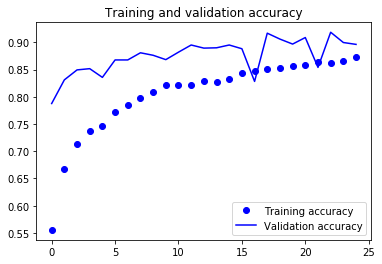

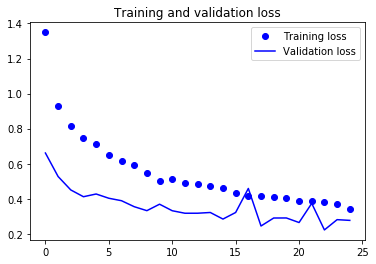

In [48]:
plot_accuracy_error(history)

In [49]:
#train and validation have comparable accuracies. 

### Final Model  Evaluation

In [50]:
model_accuracy(model, X_train,  y_train, X_validate,  y_validate)

EVALUATION OF TRAIN :

219/219 [==============================] - 12s 55ms/step - loss: 0.2287 - accuracy: 0.9091
[0.2287445068359375, 0.9091429114341736]

EVALUATION OF VALIDATE :

55/55 [==============================] - 2s 43ms/step - loss: 0.2764 - accuracy: 0.8965
[0.27642062306404114, 0.8964530825614929]
Instructions for updating:
Please use instead:* `np.argmax(model.predict(x), axis=-1)`,   if your model does multi-class classification   (e.g. if it uses a `softmax` last-layer activation).* `(model.predict(x) > 0.5).astype("int32")`,   if your model does binary classification   (e.g. if it uses a `sigmoid` last-layer activation).

CONFUSION MATRIX FOR ACTUAL vs PREDICTED IS :
 [[153   0   0   0   5   0   5   1   2   0   0   2]
 [  0 231  11   0   0   0   0   0   0   0   2   0]
 [  0   0 150   0   0   0   0   0   1   0   0   1]
 [  0   0   0 137   0   0   1   3   0   2   1   1]
 [  5   0   1   0 105   1   0   0   0   0   0   3]
 [  3   0   1   0   1  84   0   0   0   0   0   0]


### Model Evaluation On TEst Set and preparing submission file for kaggle

In [57]:
def resize_img_test(new_shape, dir):
    listResized = []

    for i in dir: #(dir + '//' + train_df['file']):
        #if  (isfile(filename)):
        img = io.imread(i)
        img = np.asarray(img, dtype='float32')
        img = img/255

        data = transform.resize(image=img, output_shape=new_shape)
        listResized.append(data)

    return listResized;

In [58]:
X_test= resize_img_test(minimum_size_img, (test_dir +'//'+ test_df['file']))
    
X_test = np.asarray(X_test)

In [59]:
test_preds = predict_classes(X_test)

In [60]:
#labelName = []
#for i in range(len(test_preds)):
#    labelName.append(LABELS[test_preds[i]])


In [61]:
test_df['category_id'] = test_preds
test_df['species'] = [LABELS[c] for c in test_preds]
test_df[['file', 'species']].to_csv('submission.csv', index=False)

### Execution Summary

### Execution Results

In [62]:
#FINAL MODEL
#Train data is augmented using Imagegenerator and resized to minimum size 
model.summary()

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv2d (Conv2D)              (None, 49, 49, 32)        896       
_________________________________________________________________
leaky_re_lu (LeakyReLU)      (None, 49, 49, 32)        0         
_________________________________________________________________
max_pooling2d (MaxPooling2D) (None, 25, 25, 32)        0         
_________________________________________________________________
conv2d_1 (Conv2D)            (None, 25, 25, 64)        18496     
_________________________________________________________________
leaky_re_lu_1 (LeakyReLU)    (None, 25, 25, 64)        0         
_________________________________________________________________
max_pooling2d_1 (MaxPooling2 (None, 13, 13, 64)        0         
_________________________________________________________________
conv2d_2 (Conv2D)            (None, 13, 13, 128)       7

### Execution Final Result

EVALUATION OF TRAIN :

219/219 [==============================] - 12s 55ms/step - loss: 0.2287 - accuracy: 0.9091
[0.2287445068359375, 0.9091429114341736]

EVALUATION OF VALIDATE :

55/55 [==============================] - 2s 43ms/step - loss: 0.2764 - accuracy: 0.8965
[0.27642062306404114, 0.8964530825614929]
CONFUSION MATRIX FOR ACTUAL vs PREDICTED IS :
 [[153   0   0   0   5   0   5   1   2   0   0   2]
 [  0 231  11   0   0   0   0   0   0   0   2   0]
 [  0   0 150   0   0   0   0   0   1   0   0   1]
 [  0   0   0 137   0   0   1   3   0   2   1   1]
 [  5   0   1   0 105   1   0   0   0   0   0   3]
 [  3   0   1   0   1  84   0   0   0   0   0   0]
 [ 79   0   0   0   1   2  45   0   1   0   0   0]
 [  1   0   0   0   0   1   0 134   0   0   0   0]
 [  0   2   1   1   1   0   0   0  87   2   0   2]
 [  0   5   1   7   0   1   0   0   7 133   0   0]
 [  0   0   2   0   0   1   0   0   0   0  79   0]
 [  0   0   2   2   3   0   0   2   1   0   0 229]]

CLASSIFICATION REPORT IS :

              precision    recall  f1-score   support

           0       0.63      0.91      0.75       168
           1       0.97      0.95      0.96       244
           2       0.89      0.99      0.93       152
           3       0.93      0.94      0.94       145
           4       0.91      0.91      0.91       115
           5       0.93      0.94      0.94        89
           6       0.88      0.35      0.50       128
           7       0.96      0.99      0.97       136
           8       0.88      0.91      0.89        96
           9       0.97      0.86      0.91       154
          10       0.96      0.96      0.96        82
          11       0.96      0.96      0.96       239

    accuracy                           0.90      1748
   macro avg       0.91      0.89      0.89      1748
weighted avg       0.91      0.90      0.89      1748

Diagonals in Confusion Matrix indicate the actual matching with predicted count for each digit
Off diagonals indicate the incorrect match of actual and predicted for each digit


### Conclusions

----CNN basic model was able to achieve very high accuracy on train data with no augmentation. But it was overfitting model 
with accuracy very high on train dataset and huge difference in accuracy on validation set. This is because model was 
trained on exactly matching images in train set and no variations were introduced in beginning. Image augmentation led to introduction
of variation in train set and relatively varied data for training. This led to a generalized model with comparable accuracy and loss
values of train and validation data set. 

--- LeakyRelu performed better than Relu as Relu leads to stopping of black pixels

---- With dropout at CNN layer , the accuracy was reduced though the model was generalized with almost similar train and vaidation accuracy. Due to not much big count of images and less image size, seems dropout not doing any value addition


----

----- Test accuracy by uploading to kaggle was : 0.82997 [Higher accuracy seems achievable if I could run blurred and intensity modified images but memory  an issue]